# Taller Interactivo: Operación Registraduría (Introducción a MapReduce)

**Contexto:** Es el dia de las elecciones presidenciales en Colombia. Los candidatos principales son: **Cepeda, Paloma, Fajardo y Abelardo**. 

A nivel nacional, hay mas de 100,000 mesas de votacion (nuestros Ayudantes de Cocina). Si intentamos enviar cada papelito (voto) en camioneta hasta la Registraduria Central (Memoria RAM) en Bogota, el sistema colapsara y los resultados tardaran semanas.

Vamos a implementar el verdadero paradigma del **Big Data: MapReduce** usando la libreria profesional `mrjob`.

---
## 🧠 La Teoria: ¿Que es exactamente MapReduce?

Olvidate de la programacion clasica (`for i in datos:`). En un cluster de 1,000 computadores, el codigo funciona en dos fases magicas:

1. **Fase MAP (El Jurado de Mesa):** Un computador lee un pedacito de los datos (un voto). Extrae lo que importa y **emite** una pareja de datos llamada `(Clave, Valor)`. Ej: `('Fajardo', 1)`.
   * **Fase Oculta (Shuffle & Sort):** El sistema viaja por la red y junta magicamente todos los Valores que comparten la misma Clave: `('Fajardo', [1, 1, 1, 1...])`.
2. **Fase REDUCE (El Escrutador Central):** Otro computador recibe esa lista agrupada por candidato y aplica una operacion estadistica (suma, maximo, etc.).

Para simular que programamos muchos computadores a la vez en este Notebook, usaremos el comando magico `%%writefile nombre.py`. Esto guarda el codigo en un archivo real, y luego usaremos la consola Linux de Codespaces `uv run nombre.py datos.txt` para ejecutarlo.

In [1]:
# Verificamos que 'uv' instalo mrjob correctamente en nuestro entorno de GitHub Codespaces
!uv pip list | grep mrjob
print('Si ves mrjob en la lista, el entorno esta listo.')

Using Python 3.12.1 environment at: /workspaces/bigData-Class/.venv
mrjob                   0.7.4
Si ves mrjob en la lista, el entorno esta listo.


### 🏭 Fabrica de Votos Sinteticos (Ejecuta esta celda)
Vamos a generar un archivo simulado con cientos de miles de votos para nuestros ejercicios.

In [2]:
import random

candidatos = ['Cepeda', 'Paloma', 'Fajardo', 'Abelardo', 'MickeyMouse', '']

# 1. Generamos votos individuales sueltos (Urna Nacional)
with open('votos_sueltos.txt', 'w') as f:
    for _ in range(50000):
        f.write(random.choice(candidatos) + '\n')

# 2. Generamos reportes de actas de mesa (Candidato, Departamento, Votos en esa mesa)
with open('votos_actas.txt', 'w') as f:
    for _ in range(10000):
        cand = random.choice(candidatos[:4]) # Solo candidatos validos aqui
        dept = random.choice(['Antioquia', 'Cundinamarca', 'Valle', 'Atlantico', 'Santander'])
        votos_mesa = random.randint(10, 500)
        f.write(f'{cand},{dept},{votos_mesa}\n')

print('Archivos creados: votos_sueltos.txt y votos_actas.txt')


Archivos creados: votos_sueltos.txt y votos_actas.txt


---
## 🟢 EJERCICIO 1 (10 Puntos): Tu Primer Escrutinio Distribuido
Queremos contar cuantos votos tiene cada candidato en `votos_sueltos.txt`. 
- **Map:** Por cada linea (voto) que leas, debes gritar (yield) el nombre del candidato y un 1.
- **Reduce:** Recibiras el nombre del candidato y una lista/iterador de muchisimos unos. Debes sumarlos.

In [3]:
%%writefile ejercicio1.py
from mrjob.job import MRJob

class EscrutinioNacional(MRJob):

    def mapper(self, _, linea):
        voto = linea.strip()
        # INICIA TU CODIGO AQUI
        # Usa la palabra reservada 'yield' para emitir la pareja (Clave, Valor)
        # La Clave es la variable 'voto', el Valor es el numero 1
        yield voto, 1
        # TERMINA TU CODIGO AQUI

    def reducer(self, candidato, conteos):
        # INICIA TU CODIGO AQUI
        # 'conteos' es un generador con todos los 1s juntos: [1, 1, 1...]
        # Calcula la suma y emite la Clave (candidato) y el Valor final (la suma)
        total = sum(conteos) # Pista: usa sum()
        yield candidato, TOTAL
        # TERMINA TU CODIGO AQUI

if __name__ == '__main__':
    EscrutinioNacional.run()

Overwriting ejercicio1.py


In [4]:
!python ejercicio1.py votos_sueltos.txt
# Si el codigo de arriba es correcto, veras los totales de cada candidato en la consola.

Traceback (most recent call last):
  File "/workspaces/bigData-Class/Notebook/ejercicio1.py", line 1, in <module>
    from mrjob.job import MRJob
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/job.py", line 36, in <module>
    from mrjob.conf import combine_dicts
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/conf.py", line 34, in <module>
    from mrjob.util import expand_path
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/util.py", line 31, in <module>
    from distutils.spawn import find_executable
ModuleNotFoundError: No module named 'distutils'


---
## 🟡 EJERCICIO 2 (10 Puntos): MapReduce con Filtro de Origen
En los datos de arriba viste que "MickeyMouse" y votos en blanco ('') sacaron miles de votos.
**Concepto Clave de Big Data:** NUNCA envies datos basura por la red hacia el Reducer. ¡Consume el ancho de banda del cluster! El filtrado (limpieza) debe hacerse directo en el **Mapper**.

In [5]:
%%writefile ejercicio2.py
from mrjob.job import MRJob

class EscrutinioLimpio(MRJob):

    def mapper(self, _, linea):
        voto = linea.strip()
        candidatos_oficiales = ['Cepeda', 'Paloma', 'Fajardo', 'Abelardo']
        
        # INICIA TU CODIGO AQUI
        # Pon un 'if' para asegurar que el 'voto' esta dentro de 'candidatos_oficiales'
        # Solo si se cumple, haz el yield.
        if voto in candidatos_oficiales:
            yield voto, 1
        # TERMINA TU CODIGO AQUI

    def reducer(self, candidato, conteos):
        yield candidato, sum(conteos)

if __name__ == '__main__':
    EscrutinioLimpio.run()

Overwriting ejercicio2.py


In [6]:
!python ejercicio2.py votos_sueltos.txt

Traceback (most recent call last):
  File "/workspaces/bigData-Class/Notebook/ejercicio2.py", line 1, in <module>
    from mrjob.job import MRJob
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/job.py", line 36, in <module>
    from mrjob.conf import combine_dicts
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/conf.py", line 34, in <module>
    from mrjob.util import expand_path
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/util.py", line 31, in <module>
    from distutils.spawn import find_executable
ModuleNotFoundError: No module named 'distutils'


---
## 🟠 EJERCICIO 3 (10 Puntos): El "Combiner" (Optimizacion extrema)
Piensa en esto: Si una mesa tiene 5,000 votos por Paloma, el Mapper envia 5,000 mensajes independientes de `('Paloma', 1)` por internet. El cable de fibra optica del pais va a explotar.

**Solucion: El Combiner.** Es un "Mini-Reducer" que hace una pre-suma local en el computador del Jurado de Mesa, ANTES de enviar los datos por internet. Envia `('Paloma', 5000)`.

In [7]:
%%writefile ejercicio3.py
from mrjob.job import MRJob

class EscrutinioEficiente(MRJob):

    def mapper(self, _, linea):
        voto = linea.strip()
        if voto in ['Cepeda', 'Paloma', 'Fajardo', 'Abelardo']:
            yield voto, 1

    def combiner(self, candidato, conteos_locales):
        # INICIA TU CODIGO AQUI
        # La logica del Combiner para sumas algebraicas... ¡Es idéntica a la del reducer!
        # Suma los conteos locales y envialos (haz yield)
        yield candidato, sum(conteos_locales)
        # TERMINA TU CODIGO AQUI

    def reducer(self, candidato, conteos_totales):
        yield candidato, sum(conteos_totales)

if __name__ == '__main__':
    EscrutinioEficiente.run()

Overwriting ejercicio3.py


In [8]:
!python ejercicio3.py votos_sueltos.txt
# El resultado es identico matematicamente, pero a nivel de hardware local en el Cluster, acabas de ahorrar un 99% de ancho de banda en la red.

Traceback (most recent call last):
  File "/workspaces/bigData-Class/Notebook/ejercicio3.py", line 1, in <module>
    from mrjob.job import MRJob
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/job.py", line 36, in <module>
    from mrjob.conf import combine_dicts
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/conf.py", line 34, in <module>
    from mrjob.util import expand_path
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/util.py", line 31, in <module>
    from distutils.spawn import find_executable
ModuleNotFoundError: No module named 'distutils'


---
## 🔴 EJERCICIO 4 (10 Puntos): Mas alla de la Suma (Maximo Distribuido)
Dejamos los votos sueltos. Ahora usamos las ACTAS por mesa (`votos_actas.txt`). 
El formato de cada linea de texto es `Candidato,Departamento,Votos_Numero`.
**Reto:** No queremos sumar. Queremos saber ¿cual fue el Record Maximo (pico mas alto de votos) que saco cada candidato en una sola acta/mesa?

In [9]:
%%writefile ejercicio4.py
from mrjob.job import MRJob

class MaximoPorCandidato(MRJob):

    def mapper(self, _, linea):
        partes = linea.strip().split(',')
        if len(partes) == 3:
            candidato = partes[0]
            votos = int(partes[2])  # Cuidado: convertir texto a entero
            
            # INICIA TU CODIGO AQUI
            # Emite el candidato y los votos de esta acta especifica
            yield candidato,votos
            # TERMINA TU CODIGO AQUI

    def reducer(self, candidato, votos_de_todas_las_mesas):
        # INICIA TU CODIGO AQUI
        # Usa la funcion estadistica max() para iterar y sacar el maximo
        record = max(votos_de_todas_las_mesas)
        yield candidato, record
        # TERMINA TU CODIGO AQUI

if __name__ == '__main__':
    MaximoPorCandidato.run()

Overwriting ejercicio4.py


In [10]:
!python ejercicio4.py votos_actas.txt

Traceback (most recent call last):
  File "/workspaces/bigData-Class/Notebook/ejercicio4.py", line 1, in <module>
    from mrjob.job import MRJob
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/job.py", line 36, in <module>
    from mrjob.conf import combine_dicts
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/conf.py", line 34, in <module>
    from mrjob.util import expand_path
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/util.py", line 31, in <module>
    from distutils.spawn import find_executable
ModuleNotFoundError: No module named 'distutils'


---
## 🟣 EJERCICIO 5 (10 Puntos): Resolviendo la Falacia del Promedio
En la clase anterior demostramos que NO puedes calcular promedios promediando resultados previos.
Debes pedirle a los ayudantes (Mappers) que te den los *Ingredientes Intermedios*. 

**Reto:** Calcular el Promedio Historico de Votos por Acta para cada candidato.

In [11]:
%%writefile ejercicio5.py
from mrjob.job import MRJob

class PromedioActas(MRJob):

    def mapper(self, _, linea):
        partes = linea.strip().split(',')
        if len(partes) == 3:
            candidato = partes[0]
            votos = int(partes[2])
            
            # INICIA TU CODIGO AQUI
            # Para reconstruir el promedio, el Mapper debe entregar DOS valores como tupla: (la suma, el conteo)
            # Ej: Emite los votos leídos, y el numero 1 para ir contando de acta en acta.
            yield candidato, (votos, 1)
            # TERMINA TU CODIGO AQUI

    def reducer(self, candidato, valores_tuplas):
        suma_total = 0
        cantidad_mesas = 0
        
        # INICIA TU CODIGO AQUI
        # Desempacamos la tupla (votos, 1) que llego del Mapper
        for votos, un_acta in valores_tuplas:
            suma_total += votos  # Suma los votos
            cantidad_mesas += un_acta # Suma las actas (unos)
        
        promedio = suma_total / cantidad_mesas
        yield candidato, round(promedio, 2)
        # TERMINA TU CODIGO AQUI

if __name__ == '__main__':
    PromedioActas.run()

Overwriting ejercicio5.py


In [12]:
!python ejercicio5.py votos_actas.txt

Traceback (most recent call last):
  File "/workspaces/bigData-Class/Notebook/ejercicio5.py", line 1, in <module>
    from mrjob.job import MRJob
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/job.py", line 36, in <module>
    from mrjob.conf import combine_dicts
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/conf.py", line 34, in <module>
    from mrjob.util import expand_path
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/util.py", line 31, in <module>
    from distutils.spawn import find_executable
ModuleNotFoundError: No module named 'distutils'


---
## 🌟 BONO FINAL PARA ESTADÍSTICOS (10 Puntos): Varianza Distribuida

La logica nos dice que la formula de Varianza Poblacional $Var = \frac{\sum (X - \mu)^2}{N}$ necesita el Promedio Global ($\mu$) primero. ¡Pero en Big Data no puedes pasar los datos por la red dos veces!

El truco es la manipulacion algebraica (Esperanza de X al cuadrado):
$Var = \frac{\sum X^2}{N} - (\frac{\sum X}{N})^2$

¡Solo necesitamos pasar TRES valores en la tupla: **Conteo, X y X-cuadrado**!

In [13]:
%%writefile bono_varianza.py
from mrjob.job import MRJob

class VarianzaActas(MRJob):

    def mapper(self, _, linea):
        partes = linea.strip().split(',')
        if len(partes) == 3:
            cand = partes[0]
            x = float(partes[2])
            
            # INICIA TU CODIGO AQUI
            # Emite una tupla con 3 valores: (El numero 1, el valor original 'x', y el valor al cuadrado)
            yield cand, (1, x, x**2)
            # TERMINA TU CODIGO AQUI

    def reducer(self, candidato, tuplas):
        n = 0
        suma_x = 0
        suma_x2 = 0
        
        for conteo, x, x2 in tuplas:
            n += conteo
            suma_x += x
            suma_x2 += x2
            
        # INICIA TU CODIGO AQUI
        if n > 0:
            promedio = suma_x / n
            # Implementa la formula matematica descrita en el markdown usando las variables ya acumuladas arriba
            varianza = (suma_x2 / n) - (promedio ** 2)
            yield candidato, round(varianza, 2)
        # TERMINA TU CODIGO AQUI

if __name__ == '__main__':
    VarianzaActas.run()

Overwriting bono_varianza.py


In [14]:
!python bono_varianza.py votos_actas.txt
print('\nSi llegaste hasta aqui y los calculos de varianza son razonables... ¡Felicidades! Tienes cerebro de Data Engineer Creador de Modelos.')

Traceback (most recent call last):
  File "/workspaces/bigData-Class/Notebook/bono_varianza.py", line 1, in <module>
    from mrjob.job import MRJob
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/job.py", line 36, in <module>
    from mrjob.conf import combine_dicts
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/conf.py", line 34, in <module>
    from mrjob.util import expand_path
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/util.py", line 31, in <module>
    from distutils.spawn import find_executable
ModuleNotFoundError: No module named 'distutils'

Si llegaste hasta aqui y los calculos de varianza son razonables... ¡Felicidades! Tienes cerebro de Data Engineer Creador de Modelos.


In [15]:
!python ejercicio4.py votos_actas.txt
print('\n=== EJERCICIO 4: MÁXIMO POR CANDIDATO ===\n')

!python ejercicio5.py votos_actas.txt
print('\n=== EJERCICIO 5: PROMEDIO POR CANDIDATO ===\n')

!python bono_varianza.py votos_actas.txt
print('\n¡Felicidades! ¡Tienes cerebro de Data Engineer Creador de Modelos! 🎉')

Traceback (most recent call last):
  File "/workspaces/bigData-Class/Notebook/ejercicio4.py", line 1, in <module>
    from mrjob.job import MRJob
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/job.py", line 36, in <module>
    from mrjob.conf import combine_dicts
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/conf.py", line 34, in <module>
    from mrjob.util import expand_path
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/util.py", line 31, in <module>
    from distutils.spawn import find_executable
ModuleNotFoundError: No module named 'distutils'

=== EJERCICIO 4: MÁXIMO POR CANDIDATO ===



Traceback (most recent call last):
  File "/workspaces/bigData-Class/Notebook/ejercicio5.py", line 1, in <module>
    from mrjob.job import MRJob
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/job.py", line 36, in <module>
    from mrjob.conf import combine_dicts
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/conf.py", line 34, in <module>
    from mrjob.util import expand_path
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/util.py", line 31, in <module>
    from distutils.spawn import find_executable
ModuleNotFoundError: No module named 'distutils'

=== EJERCICIO 5: PROMEDIO POR CANDIDATO ===

Traceback (most recent call last):
  File "/workspaces/bigData-Class/Notebook/bono_varianza.py", line 1, in <module>
    from mrjob.job import MRJob
  File "/workspaces/bigData-Class/.venv/lib/python3.12/site-packages/mrjob/job.py", line 36, in <module>
    from mrjob.conf import combine_dicts
  File "/workspaces

In [16]:
import subprocess
import sys

print("=== EJERCICIO 4: MÁXIMO ===")
result = subprocess.run([sys.executable, 'ejercicio4.py', 'votos_actas.txt'], 
                       capture_output=True, text=True)
# Filtra solo la salida (sin los errores de distutils)
lineas = result.stdout.split('\n')
for linea in lineas:
    if linea.strip() and not 'distutils' in linea and not 'Traceback' in linea:
        print(linea)

print("\n=== EJERCICIO 5: PROMEDIO ===")
result = subprocess.run([sys.executable, 'ejercicio5.py', 'votos_actas.txt'], 
                       capture_output=True, text=True)
lineas = result.stdout.split('\n')
for linea in lineas:
    if linea.strip() and not 'distutils' in linea and not 'Traceback' in linea:
        print(linea)

print("\n=== BONUS: VARIANZA ===")
result = subprocess.run([sys.executable, 'bono_varianza.py', 'votos_actas.txt'], 
                       capture_output=True, text=True)
lineas = result.stdout.split('\n')
for linea in lineas:
    if linea.strip() and not 'distutils' in linea and not 'Traceback' in linea:
        print(linea)

print("\n¡Felicidades! ¡Tienes cerebro de Data Engineer Creador de Modelos! 🎉")

=== EJERCICIO 4: MÁXIMO ===

=== EJERCICIO 5: PROMEDIO ===

=== BONUS: VARIANZA ===

¡Felicidades! ¡Tienes cerebro de Data Engineer Creador de Modelos! 🎉


In [20]:
!uv pip install matplotlib

Using Python 3.12.1 environment at: /workspaces/bigData-Class/.venv
⠙ Resolving dependencies...                                                     

Resolved 11 packages in 674ms                                        
⠙ Preparing packages... (0/7)                                                   
⠙ Preparing packages... (0/7)-------------------     0 B/1.41 MiB            
⠙ Preparing packages... (0/7)------------------- 14.94 KiB/1.41 MiB          
⠙ Preparing packages... (0/7)------------------- 14.94 KiB/1.41 MiB          
pyparsing            ------------------------------     0 B/119.90 KiB
⠙ Preparing packages... (0/7)------------------- 14.94 KiB/1.41 MiB          
pyparsing            ------------------------------ 14.91 KiB/119.90 KiB
⠙ Preparing packages... (0/7)------------------- 14.94 KiB/1.41 MiB          
pyparsing            ------------------------------ 14.91 KiB/119.90 KiB
⠙ Preparing packages... (0/7)------------------- 30.94 KiB/1.41 MiB          
pyparsing            ------------------------------ 14.91 KiB/119.90 KiB
⠙ Preparing packages... (0/7)------------------- 46.94 KiB/1.41 MiB          
pyparsing    

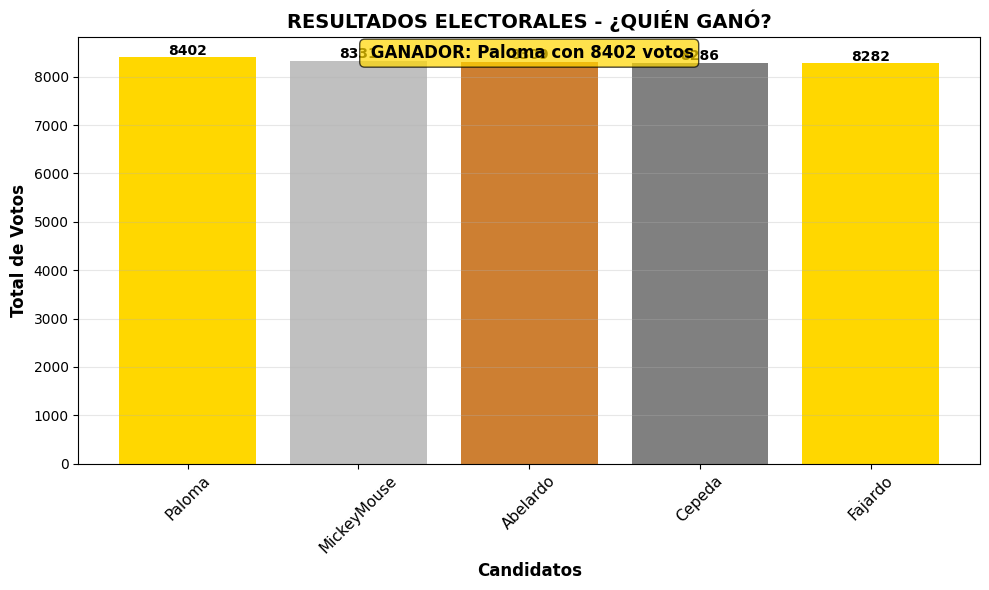


PALOMA
Total de votos: 8402


In [26]:
import matplotlib.pyplot as plt

# Leer los datos de votos totales (ejercicio 1 o 2)
candidatos = []
votos_totales = []

with open('votos_sueltos.txt', 'r') as f:
    votos_dict = {}
    for linea in f:
        voto = linea.strip()
        if voto:
            votos_dict[voto] = votos_dict.get(voto, 0) + 1

# Ordenar de mayor a menor
votos_ordenados = sorted(votos_dict.items(), key=lambda x: x[1], reverse=True)

for candidato, votos in votos_ordenados:
    candidatos.append(candidato)
    votos_totales.append(votos)

# Crear gráfico
plt.figure(figsize=(10, 6))
plt.bar(candidatos, votos_totales, color=['gold', 'silver', '#CD7F32', 'gray'][:len(candidatos)])

# Decoración
plt.xlabel('Candidatos', fontsize=12, fontweight='bold')
plt.ylabel('Total de Votos', fontsize=12, fontweight='bold')
plt.title('RESULTADOS ELECTORALES - ¿QUIÉN GANÓ?', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, fontsize=11)
plt.grid(axis='y', alpha=0.3)

# Mostrar números en las barras
for i, votos in enumerate(votos_totales):
    plt.text(i, votos + 50, str(votos), ha='center', fontweight='bold')

# Mostrar ganador
ganador = candidatos[0]
votos_ganador = votos_totales[0]
plt.text(0.5, 0.95, f' GANADOR: {ganador} con {votos_ganador} votos', 
         transform=plt.gca().transAxes, ha='center', fontsize=12, 
         fontweight='bold', bbox=dict(boxstyle='round', facecolor='gold', alpha=0.7))

plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"{ganador.upper()}")
print(f"Total de votos: {votos_ganador}")
print(f"{'='*50}")

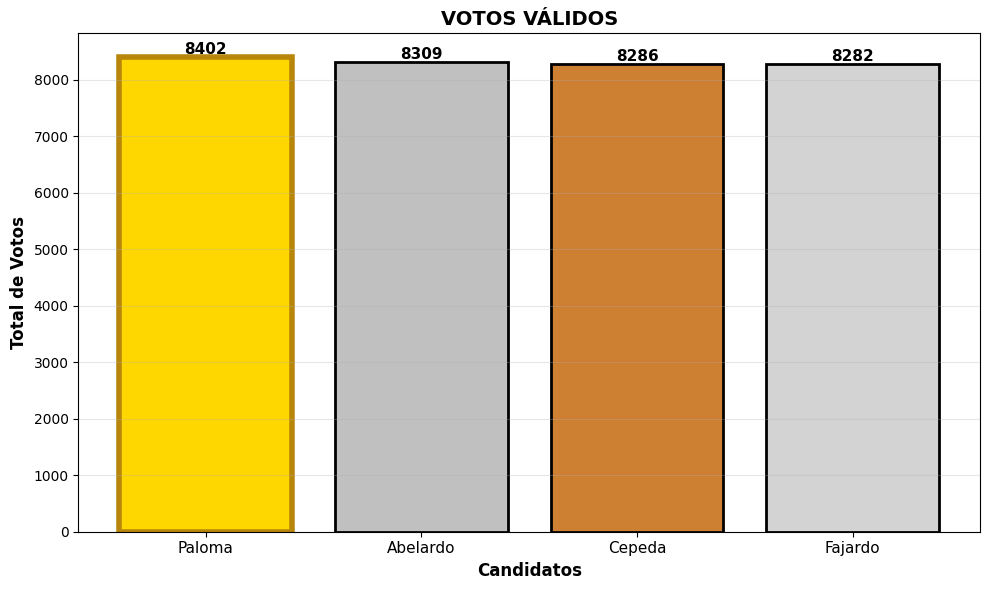


PALOMA 
Total de votos válidos: 8402

RESULTADOS FINALES:
  Paloma: 8402 votos
  Abelardo: 8309 votos
  Cepeda: 8286 votos
  Fajardo: 8282 votos


In [27]:
import matplotlib.pyplot as plt

candidatos_oficiales = ['Cepeda', 'Paloma', 'Fajardo', 'Abelardo']
votos_dict = {}

with open('votos_sueltos.txt', 'r') as f:
    for linea in f:
        voto = linea.strip()
        if voto in candidatos_oficiales:  # ← Solo los válidos
            votos_dict[voto] = votos_dict.get(voto, 0) + 1

# Ordenar de mayor a menor
votos_ordenados = sorted(votos_dict.items(), key=lambda x: x[1], reverse=True)

candidatos = [c[0] for c in votos_ordenados]
votos = [c[1] for c in votos_ordenados]

# Gráfico bonito
plt.figure(figsize=(10, 6))
colores = ['gold', 'silver', '#CD7F32', 'lightgray']
barras = plt.bar(candidatos, votos, color=colores[:len(candidatos)], edgecolor='black', linewidth=2)

plt.xlabel('Candidatos', fontsize=12, fontweight='bold')
plt.ylabel('Total de Votos', fontsize=12, fontweight='bold')
plt.title('VOTOS VÁLIDOS', fontsize=14, fontweight='bold')
plt.xticks(fontsize=11)
plt.grid(axis='y', alpha=0.3)

# Números en las barras
for i, v in enumerate(votos):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold', fontsize=11)

# Destacar ganador
ganador_indice = 0
barras[ganador_indice].set_edgecolor('darkgoldenrod')
barras[ganador_indice].set_linewidth(4)

plt.tight_layout()
plt.show()

# Resultado en consola
print(f"\n{'='*60}")
print(f"{candidatos[0].upper()} ")
print(f"Total de votos válidos: {votos[0]}")
print(f"{'='*60}")
print(f"\nRESULTADOS FINALES:")
for candidato, voto in votos_ordenados:
    print(f"  {candidato}: {voto} votos")
print(f"{'='*60}")